In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Dataset

New dataset that includes newly created variables:
- **New minority quintiles:**
    - Black Quintile (1 - highest black percentage, 5 - lowest black percentage)
    - Black, Native, other Quintile (non-white non-asian population: black of african american, american indiain or alaska native, native hawaiian or pacicfic islander, other race, two or more races)
- **New continuous variables for city fixed effects:**
    - Median income in the zip (divided by 10k)
    - Share of population with bachelor or higher degree
- **Other variables as previously:**
    - Income Quintiles (1 - lowest median income, 5 - highest median income )
    - Education Quintiles (1 - lowest percent bachelor education or higher, 5 - highest percent bachelor education or higher )


### Loading the dataset

In [ ]:
cols = [
    "income_quintile",
    "minority_quintile",
    "education_quintile",
    "black_quintile",
    "black_native_other_quintile"
]

dtype_map = {c: "Int8" for c in cols}   # nullable integer type

df = pd.read_csv(
    "new_merged_aggregated.csv",
    index_col=0,
    dtype=dtype_map
)

### Merged with insitution classification

In [4]:
ai_adopt_df = pd.read_excel("ai_adoption.xlsx")
ai_adopt_df = ai_adopt_df[['Company', 'Fintech?']]
ai_adopt_df.head()

,Company,Fintech?
0,"EQUIFAX, INC.",credit bureat
1,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",credit bureat
2,Experian Information Solutions Inc.,credit bureat
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",non fintech
4,WELLS FARGO & COMPANY,non fintech


In [5]:
mask = (
    (ai_adopt_df.index < 100) | 
    ((ai_adopt_df.index >= 100) & (ai_adopt_df['Fintech?'] == 'fintech'))
)
filtered_ai_adopt_df = ai_adopt_df[mask].copy()

In [6]:
# Keep only relevant categories
filtered_ai_adopt_df = filtered_ai_adopt_df[
    filtered_ai_adopt_df['Fintech?'].isin(['non fintech', 'fintech'])
]

In [ ]:
# Report statistics
print(f"Total companies: {len(filtered_ai_adopt_df)}")
print(f"Fintechs: {(filtered_ai_adopt_df['Fintech?'] == 'fintech').sum()}")
print(f"Non-Fintechs: {(filtered_ai_adopt_df['Fintech?'] == 'non fintech').sum()}")

Total companies: 108
Fintechs: 26
Non-Fintechs: 82


In [8]:
# Create binary fintech indicator
filtered_ai_adopt_df['Fintech'] = (
    filtered_ai_adopt_df['Fintech?'].str.lower() == 'fintech'
).astype(int)

In [9]:
# Merge datasets using case-insensitive matching
merged_df = df.merge(
    filtered_ai_adopt_df[['Company', 'Fintech']],
    left_on=df['Company'].str.lower(),
    right_on=filtered_ai_adopt_df['Company'].str.lower(),
    how='left',
    suffixes=('', '_right')
).drop(columns=['key_0', 'Company_right'], errors='ignore')

### Dropping rows with companies that we didn't classify and any rows with blank demographic data

In [10]:
print(f'Records before dropna: {len(merged_df)}')
merged_df = merged_df.dropna()
print(f'Records after dropna: {len(merged_df)}')

Records before dropna: 2369594
Records after dropna: 1701381


In [11]:
merged_df.columns

Index(['ZIP code', 'month', 'Company', 'num_complaints', 'income_quintile',
       'minority_quintile', 'education_quintile', 'population_total',
       'income_zip_10k', 'share_bach_or_higher_zip', 'black_quintile',
       'black_native_other_quintile', 'Fintech'],
      dtype='object')

### Dummy variables

Dropping the first one to have as baseline

In [12]:
cols_to_encode = [
    'income_quintile', 'minority_quintile', 'education_quintile', 
    'Fintech', 'black_quintile', 'black_native_other_quintile'
]


merged_df = pd.get_dummies(
    merged_df, 
    columns=cols_to_encode, 
    drop_first=True
)

merged_df.head()

,ZIP code,month,Company,num_complaints,population_total,income_zip_10k,share_bach_or_higher_zip,income_quintile_2,income_quintile_3,income_quintile_4,income_quintile_5,minority_quintile_2,minority_quintile_3,minority_quintile_4,minority_quintile_5,education_quintile_2,education_quintile_3,education_quintile_4,education_quintile_5,Fintech_1.0,black_quintile_2,black_quintile_3,black_quintile_4,black_quintile_5,black_native_other_quintile_2,black_native_other_quintile_3,black_native_other_quintile_4,black_native_other_quintile_5
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,60620,2025-01,"Early Warning Services, LLC",87,66514.0,3.9499,0.182574,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False
2,33071,2012-06,Ocwen Financial Corporation,74,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
3,60629,2025-01,"Early Warning Services, LLC",66,114453.0,4.3372,0.110897,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
4,60628,2025-01,"Block, Inc.",61,62832.0,4.4410,0.216936,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False


### Number of complaints normalization (population)

Mimicking normalization from previous modelling: 
- by population total by zip-code (per 1000 inhabitants), 
- log transformation

In [13]:
merged_df['norm_num_complaints'] = (merged_df['num_complaints'] / merged_df['population_total']) * 1000

In [14]:
print("pre normalization\n",merged_df['num_complaints'].describe())
print("post normalization\n",merged_df['norm_num_complaints'].describe())

pre normalization
 count    1.701381e+06
mean     1.145770e+00
std      6.852932e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.960000e+02
Name: num_complaints, dtype: float64
post normalization
 count    1.701381e+06
mean     5.606848e-02
std      5.796299e-01
min      7.393387e-03
25%      2.122331e-02
50%      3.000300e-02
75%      4.456527e-02
max      2.500000e+02
Name: norm_num_complaints, dtype: float64


In [15]:
merged_df['log_norm_num_complaints'] = np.log1p(merged_df['norm_num_complaints'])
merged_df['log_norm_num_complaints'].describe()

count    1.701381e+06
mean     4.746442e-02
std      8.710332e-02
min      7.366190e-03
25%      2.100123e-02
50%      2.956172e-02
75%      4.360079e-02
max      5.525453e+00
Name: log_norm_num_complaints, dtype: float64

## Modelling

### Preparation of the variables for modelling

Defining which quintiles to consider for each area:

In [16]:
Q_m = "black_native_other_quintile"  # Minority quintile
Q_i = "income_quintile"               # Income quintile
Q_e = "education_quintile"            # Education quintile

In [17]:
# Create continuous time trend variable
merged_df['month_dt'] = pd.to_datetime(merged_df['month'])
merged_df['time_trend'] = (merged_df['month_dt'].dt.year - merged_df['month_dt'].dt.year.min()) * 12 + \
                          (merged_df['month_dt'].dt.month - 1)

print(f"Time trend ranges from {merged_df['time_trend'].min()} to {merged_df['time_trend'].max()}")
print(f"Unique time periods: {merged_df['time_trend'].nunique()}")

Time trend ranges from 11 to 177
Unique time periods: 167


In [18]:
merged_df.head(5)

,ZIP code,month,Company,num_complaints,population_total,income_zip_10k,share_bach_or_higher_zip,income_quintile_2,income_quintile_3,income_quintile_4,income_quintile_5,minority_quintile_2,minority_quintile_3,minority_quintile_4,minority_quintile_5,education_quintile_2,education_quintile_3,education_quintile_4,education_quintile_5,Fintech_1.0,black_quintile_2,black_quintile_3,black_quintile_4,black_quintile_5,black_native_other_quintile_2,black_native_other_quintile_3,black_native_other_quintile_4,black_native_other_quintile_5,norm_num_complaints,log_norm_num_complaints,month_dt,time_trend
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,4.896817,1.774413,2012-06-01,17
1,60620,2025-01,"Early Warning Services, LLC",87,66514.0,3.9499,0.182574,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,1.307995,0.836379,2025-01-01,168
2,33071,2012-06,Ocwen Financial Corporation,74,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,1.848798,1.046897,2012-06-01,17
3,60629,2025-01,"Early Warning Services, LLC",66,114453.0,4.3372,0.110897,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,0.576656,0.455306,2025-01-01,168
4,60628,2025-01,"Block, Inc.",61,62832.0,4.4410,0.216936,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,0.970843,0.678461,2025-01-01,168


In [19]:
# Create interaction terms: Fintech × all minority quintile dummies
# Convert to numeric first to avoid the boolean warning
for i in range(2, 6):
    merged_df[f'fintech_x_qm_{i}'] = merged_df['Fintech_1.0'].astype(int) * merged_df[f'{Q_m}_{i}'].astype(int)

print("Interaction terms created:")
print([col for col in merged_df.columns if 'fintech_x_qm' in col])

Interaction terms created:
['fintech_x_qm_2', 'fintech_x_qm_3', 'fintech_x_qm_4', 'fintech_x_qm_5']


In [20]:
# Base components
base_controls = 'C(Company) + time_trend'

# Quintile dummies (using our defined variable names)
qm_dummies = ' + '.join([f'{Q_m}_{i}' for i in range(2, 6)])
qi_dummies = ' + '.join([f'{Q_i}_{i}' for i in range(2, 6)])
qe_dummies = ' + '.join([f'{Q_e}_{i}' for i in range(2, 6)])

# Fintech × Qm interactions
fintech_qm_interaction = ' + '.join([f'fintech_x_qm_{i}' for i in range(2, 6)])

# Continuous controls
continuous_controls = 'income_zip_10k + share_bach_or_higher_zip'

### Model definitions

In [ ]:
# Model Family 1: Minority quintile dummies (Qm)
model_1a = f'log_norm_num_complaints ~ {qm_dummies} + {base_controls}'
model_1b = f'log_norm_num_complaints ~ {qm_dummies} + {fintech_qm_interaction} + {base_controls}'
model_1c = f'log_norm_num_complaints ~ {qm_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 2: Income quintile dummies (Qi)
model_2a = f'log_norm_num_complaints ~ {qi_dummies} + {base_controls}'
model_2b = f'log_norm_num_complaints ~ {qi_dummies} + {fintech_qm_interaction} + {base_controls}'
model_2c = f'log_norm_num_complaints ~ {qi_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 3: Education quintile dummies (Qe)
model_3a = f'log_norm_num_complaints ~ {qe_dummies} + {base_controls}'
model_3b = f'log_norm_num_complaints ~ {qe_dummies} + {fintech_qm_interaction} + {base_controls}'
model_3c = f'log_norm_num_complaints ~ {qe_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 4: All quintile dummies (Qm + Qi + Qe)
model_4a = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {base_controls}'
model_4b = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {fintech_qm_interaction} + {base_controls}'
model_4c = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

### Run all models

In [22]:
# Dictionary to store results
results = {}

# Model specifications
model_specs = {
    '1a': model_1a, '1b': model_1b, '1c': model_1c,
    '2a': model_2a, '2b': model_2b, '2c': model_2c,
    '3a': model_3a, '3b': model_3b, '3c': model_3c,
    '4a': model_4a, '4b': model_4b, '4c': model_4c
}

# Run each model with clustered standard errors at Company level
print("Running regressions...\n")
for name, formula in model_specs.items():
    print(f"Model {name}...", end=' ')
    try:
        model = smf.ols(formula=formula, data=merged_df)
        # Fit with clustered standard errors at Company level
        result = model.fit(cov_type='cluster', cov_kwds={'groups': merged_df['Company']})
        results[name] = result
        print(f"✓ (N={result.nobs:,}, R²={result.rsquared:.4f})")
    except Exception as e:
        print(f"✗ FAILED: {str(e)}")

print(f"\n{'='*60}")
print(f"Completed {len(results)}/12 models successfully")
print(f"{'='*60}")

Running regressions...

Model 1a... ✓ (N=1,701,381.0, R²=0.1096)
Model 1b... ✓ (N=1,701,381.0, R²=0.1099)
Model 1c... ✓ (N=1,701,381.0, R²=0.1235)
Model 2a... ✓ (N=1,701,381.0, R²=0.0113)
Model 2b... ✓ (N=1,701,381.0, R²=0.0195)
Model 2c... ✓ (N=1,701,381.0, R²=0.0236)
Model 3a... ✓ (N=1,701,381.0, R²=0.0250)
Model 3b... ✓ (N=1,701,381.0, R²=0.0330)
Model 3c... ✓ (N=1,701,381.0, R²=0.0331)
Model 4a... ✓ (N=1,701,381.0, R²=0.1342)
Model 4b... ✓ (N=1,701,381.0, R²=0.1345)
Model 4c... ✓ (N=1,701,381.0, R²=0.1346)

Completed 12/12 models successfully


### Helper function definition
Defining a function to print results except for the coefficients for each of the company fixed effects

In [27]:
def remove_company_rows(smry, prefix="C(Company)"):
    """
    Remove coefficient and standard error rows from a summary_col() Summary object where the row label starts with a given prefix.
    
    """
    tbl = smry.tables[0]  # pandas DataFrame

    idx = tbl.index.tolist()
    to_drop = []

    i = 0
    while i < len(idx):
        label = idx[i]
        if isinstance(label, str) and label.startswith(prefix):
            to_drop.append(label)   # drop this coefficient row
            # Also drop the row below if it is the SE row
            if i + 1 < len(idx) and idx[i + 1] == "":
                to_drop.append(idx[i + 1])
            i += 2
        else:
            i += 1

    # Apply the filtered table back to the summary object
    smry.tables[0] = tbl.drop(index=to_drop)

    return smry


### Model 1: Minority Results

In [28]:
print("MODEL FAMILY 1: Minority Quintile Dummies (Qm)")
print("="*70)

smry = summary_col(
    [results['1a'], results['1b'], results['1c']],
    stars=True,
    float_format='%.4f',
    model_names=['(1a)', '(1b)', '(1c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 1: Minority Quintile Dummies (Qm)


,(1a),(1b),(1c)
Intercept,0.0407***,0.0428***,0.0611***
black_native_other_quintile_2[T.True],0.0052***,0.0058***,0.0157***
black_native_other_quintile_3[T.True],0.0203***,0.0214***,0.0345***
black_native_other_quintile_4[T.True],0.0770***,0.0791***,0.0871***
black_native_other_quintile_5[T.True],0.2544***,0.2563***,0.2562***
time_trend,-0.0000***,-0.0000***,-0.0000***
fintech_x_qm_2,,-0.0043**,-0.0040**
fintech_x_qm_3,,-0.0087***,-0.0082***
fintech_x_qm_4,,-0.0191***,-0.0187***
fintech_x_qm_5,,-0.0192**,-0.0197**


### Model 2: Income Results

In [29]:
print("MODEL FAMILY 2: Income Quintile Dummies (Qi)")
print("="*70)

smry = summary_col(
    [results['2a'], results['2b'], results['2c']],
    stars=True,
    float_format='%.4f',
    model_names=['(2a)', '(2b)', '(2c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 2: Income Quintile Dummies (Qi)


,(2a),(2b),(2c)
Intercept,0.0675***,0.0627***,0.0615***
income_quintile_2[T.True],-0.0101***,-0.0105***,-0.0108***
income_quintile_3[T.True],-0.0150***,-0.0156***,-0.0158***
income_quintile_4[T.True],-0.0183***,-0.0190***,-0.0195***
income_quintile_5[T.True],-0.0208***,-0.0219***,-0.0223***
time_trend,-0.0001***,-0.0001***,-0.0001***
fintech_x_qm_2,,0.0069***,0.0092***
fintech_x_qm_3,,0.0185***,0.0209***
fintech_x_qm_4,,0.0646***,0.0644***
fintech_x_qm_5,,0.2381***,0.2361***


### Model 3: Education Results

In [30]:
print("MODEL FAMILY 3: Education Quintile Dummies (Qe)")
print("="*70)

smry = summary_col(
    [results['3a'], results['3b'], results['3c']],
    stars=True,
    float_format='%.4f',
    model_names=['(3a)', '(3b)', '(3c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 3: Education Quintile Dummies (Qe)


,(3a),(3b),(3c)
Intercept,0.0983***,0.0924***,0.0908***
education_quintile_2[T.True],-0.0286***,-0.0288***,-0.0291***
education_quintile_3[T.True],-0.0420***,-0.0422***,-0.0427***
education_quintile_4[T.True],-0.0515***,-0.0516***,-0.0525***
education_quintile_5[T.True],-0.0522***,-0.0530***,-0.0547***
time_trend,-0.0001***,-0.0001***,-0.0001***
fintech_x_qm_2,,0.0090***,0.0087***
fintech_x_qm_3,,0.0205***,0.0200***
fintech_x_qm_4,,0.0648***,0.0642***
fintech_x_qm_5,,0.2321***,0.2318***


### Model 4: All Demographics Results

In [31]:
print("MODEL FAMILY 4: All Quintile Dummies (Qm + Qi + Qe)")
print("="*70)

smry = summary_col([results['4a'], results['4b'], results['4c']], 
            stars=True,
            float_format='%.4f',
            model_names=['(4a)', '(4b)', '(4c)'],
            info_dict={'N':lambda x: f"{int(x.nobs):,}",
                      'R²':lambda x: f"{x.rsquared:.4f}",
                      'Adj. R²':lambda x: f"{x.rsquared_adj:.4f}"})
# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 4: All Quintile Dummies (Qm + Qi + Qe)


,(4a),(4b),(4c)
Intercept,0.0883***,0.0901***,0.0916***
black_native_other_quintile_2[T.True],0.0162***,0.0167***,0.0170***
black_native_other_quintile_3[T.True],0.0323***,0.0333***,0.0340***
black_native_other_quintile_4[T.True],0.0854***,0.0873***,0.0876***
black_native_other_quintile_5[T.True],0.2525***,0.2545***,0.2545***
income_quintile_2[T.True],-0.0058***,-0.0057***,-0.0056***
income_quintile_3[T.True],-0.0084***,-0.0083***,-0.0080***
income_quintile_4[T.True],-0.0099***,-0.0099***,-0.0093***
income_quintile_5[T.True],-0.0133***,-0.0133***,-0.0116***
education_quintile_2[T.True],-0.0287***,-0.0287***,-0.0280***


### All 4 models compared

In [38]:
print("ALL MODELS")
print("="*170)

smry = summary_col([results['1a'], results['1b'], results['1c'],results['2a'], results['2b'], results['2c'],
                    results['3a'], results['3b'], results['3c'],results['4a'], results['4b'], results['4c']], 
            stars=True,
            float_format='%.4f',
            model_names=['(1a)', '(1b)', '(1c)','(2a)', '(2b)', '(2c)','(3a)', '(3b)', '(3c)','(4a)', '(4b)', '(4c)'],
            info_dict={'N':lambda x: f"{int(x.nobs):,}",
                      'R²':lambda x: f"{x.rsquared:.4f}",
                      'Adj. R²':lambda x: f"{x.rsquared_adj:.4f}"})
# Clean it
smry = remove_company_rows(smry)
smry

ALL MODELS


,(1a),(1b),(1c),(2a),(2b),(2c),(3a),(3b),(3c),(4a),(4b),(4c)
Intercept,0.0407***,0.0428***,0.0611***,0.0675***,0.0627***,0.0615***,0.0983***,0.0924***,0.0908***,0.0883***,0.0901***,0.0916***
black_native_other_quintile_2[T.True],0.0052***,0.0058***,0.0157***,,,,,,,0.0162***,0.0167***,0.0170***
black_native_other_quintile_3[T.True],0.0203***,0.0214***,0.0345***,,,,,,,0.0323***,0.0333***,0.0340***
black_native_other_quintile_4[T.True],0.0770***,0.0791***,0.0871***,,,,,,,0.0854***,0.0873***,0.0876***
black_native_other_quintile_5[T.True],0.2544***,0.2563***,0.2562***,,,,,,,0.2525***,0.2545***,0.2545***
time_trend,-0.0000***,-0.0000***,-0.0000***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0000***,-0.0000***,-0.0000***
fintech_x_qm_2,,-0.0043**,-0.0040**,,0.0069***,0.0092***,,0.0090***,0.0087***,,-0.0036**,-0.0035**
fintech_x_qm_3,,-0.0087***,-0.0082***,,0.0185***,0.0209***,,0.0205***,0.0200***,,-0.0079***,-0.0078***
fintech_x_qm_4,,-0.0191***,-0.0187***,,0.0646***,0.0644***,,0.0648***,0.0642***,,-0.0184***,-0.0184***
fintech_x_qm_5,,-0.0192**,-0.0197**,,0.2381***,0.2361***,,0.2321***,0.2318***,,-0.0198**,-0.0198**


### Attempt at Lincom

In [56]:
def compute_total_effects(result, model_name):
    """Compute total effects for fintech vs non-fintech across quintiles."""
    import numpy as np
    
    # Map model to quintile variable
    quintile_map = {'1': 'black_native_other_quintile', '2': 'income_quintile', 
                    '3': 'education_quintile', '4': 'black_native_other_quintile'}
    quintile_var = quintile_map[model_name[0]]
    
    effects = []
    params, cov = result.params, result.cov_params()
    
    for q in range(2, 6):
        qvar = f'{quintile_var}_{q}[T.True]'
        intvar = f'fintech_x_qm_{q}'
        
        if qvar not in params.index:
            continue
        
        # Non-fintech (main effect only)
        main_eff, main_se = params[qvar], result.bse[qvar]
        effects.append({'Quintile': q, 'Type': 'Non-Fintech', 'Effect': main_eff, 
                       'SE': main_se, 'CI_lower': main_eff - 1.96*main_se, 
                       'CI_upper': main_eff + 1.96*main_se})
        
        # Fintech (main + interaction)
        if intvar in params.index:
            total_eff = params[qvar] + params[intvar]
            total_var = cov.loc[qvar, qvar] + cov.loc[intvar, intvar] + 2*cov.loc[qvar, intvar]
            total_se = np.sqrt(total_var)
            effects.append({'Quintile': q, 'Type': 'Fintech', 'Effect': total_eff,
                           'SE': total_se, 'CI_lower': total_eff - 1.96*total_se,
                           'CI_upper': total_eff + 1.96*total_se})
    
    return pd.DataFrame(effects)

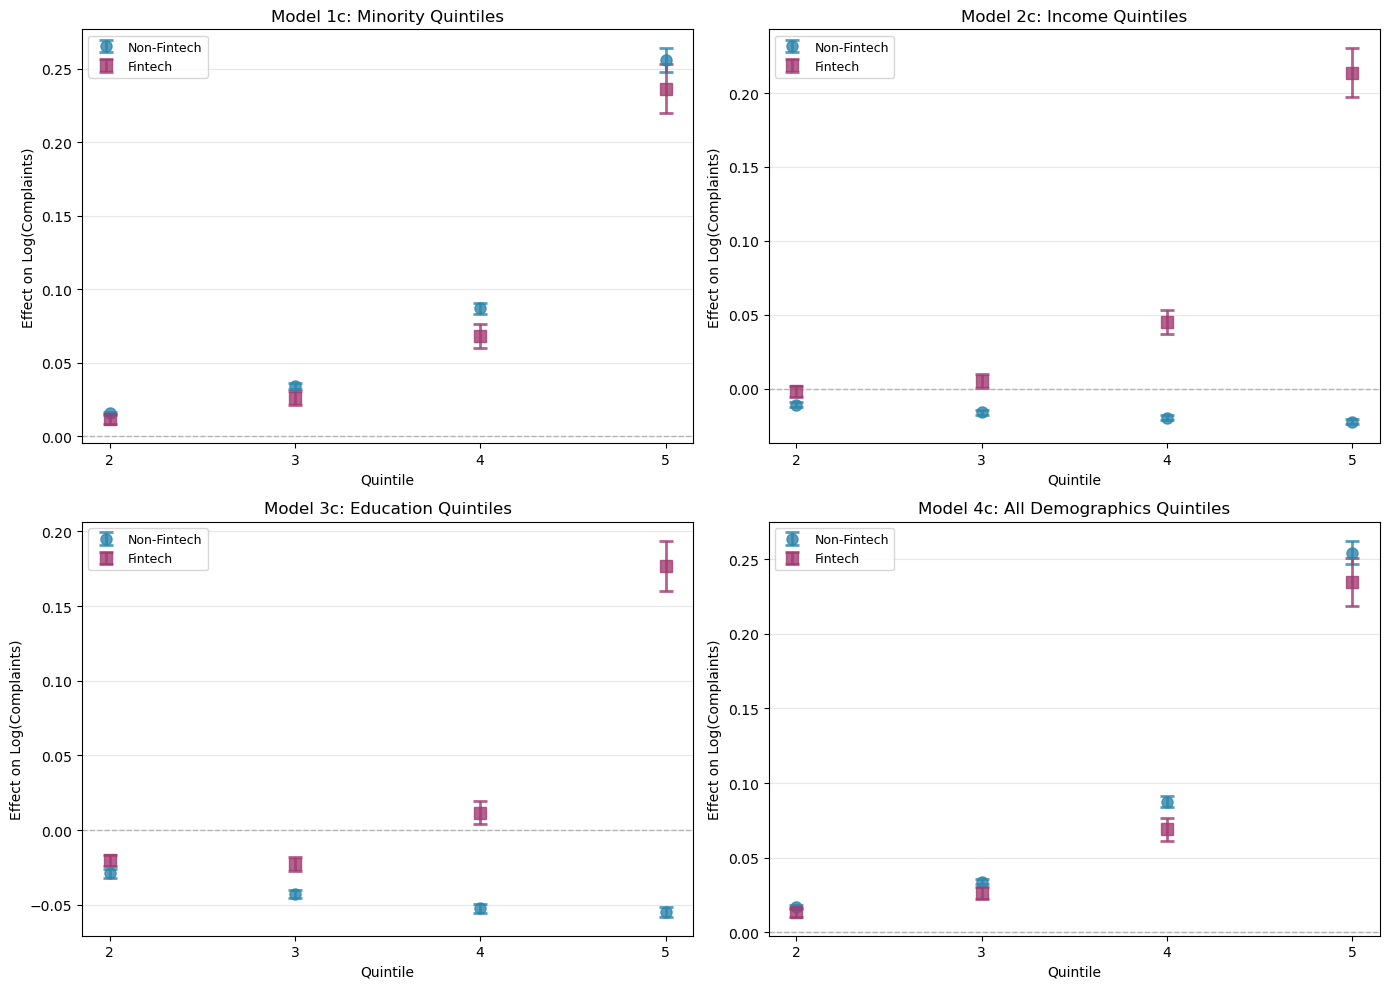


Model 4c: Combined Effects Summary
 Quintile        Type  Effect     SE  CI_lower  CI_upper
        2 Non-Fintech  0.0170 0.0006    0.0159    0.0181
        2     Fintech  0.0135 0.0016    0.0104    0.0165
        3 Non-Fintech  0.0340 0.0010    0.0321    0.0359
        3     Fintech  0.0262 0.0020    0.0223    0.0301
        4 Non-Fintech  0.0876 0.0020    0.0838    0.0915
        4     Fintech  0.0692 0.0039    0.0616    0.0769
        5 Non-Fintech  0.2545 0.0041    0.2465    0.2624
        5     Fintech  0.2346 0.0083    0.2184    0.2509


In [57]:
# Plotting
model_specs = [('1c', 'Minority'), ('2c', 'Income'), ('3c', 'Education'), ('4c', 'All Demographics')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (model_name, label), ax in zip(model_specs, axes.flatten()):
    effects_df = compute_total_effects(results[model_name], model_name)
    
    if effects_df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
    else:
        for type_name, color, marker in [('Non-Fintech', '#2E86AB', 'o'), ('Fintech', '#A23B72', 's')]:
            subset = effects_df[effects_df['Type'] == type_name]
            if not subset.empty:
                ax.errorbar(subset['Quintile'], subset['Effect'], yerr=1.96*subset['SE'],
                           fmt=marker, color=color, label=type_name, markersize=8, 
                           capsize=5, capthick=2, linewidth=2, alpha=0.8)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set(xlabel='Quintile', ylabel='Effect on Log(Complaints)', 
           title=f'Model {model_name}: {label} Quintiles', xticks=[2, 3, 4, 5])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
effects_4c = compute_total_effects(results['4c'], '4c')
print("\nModel 4c: Combined Effects Summary\n" + "="*70)
print(effects_4c.to_string(index=False, float_format=lambda x: f'{x:.4f}'))